# Merging Open Images and Fonts (Chars74K dataset)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from skimage.io import imread 
from PIL import Image
import random
import os
import os.path as osp
from tqdm import tqdm
import albumentations as A
from pathlib import Path

/home/ahabanen/.local/lib/python3.10/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def reading_in_bbox_txt_file(bbox_path) :
    bboxes = []
    file = open(bbox_path,'r')
    while True:
        content=file.readline()
        if not content:
            break
        elements = [ float(x) for x in content.strip().split(" ") ]
        bboxes.append(elements)
    file.close()

    return bboxes

In [3]:
def reading_in_background_image(background_file_names, image_path, bg_width, bg_height_old, bg_height) :

    while True:
        # Find random background image
        file_name = random.choice(background_file_names)
        background_image_path = osp.join(image_path, file_name)

        background = cv2.cvtColor(cv2.imread(background_image_path), cv2.COLOR_BGR2RGB)
        height, width, channels = background.shape

        if width == bg_width and height == bg_height_old:
            background = background[0:bg_height, 0:bg_width]
            return background, file_name
        if width == bg_height_old and height == bg_width:
            background = cv2.rotate(background, cv2.ROTATE_90_CLOCKWISE)
            background = background[0:bg_height, 0:bg_width]
            return background, file_name

def reading_in_random_digit(image_path, bbox_path, digits_files) :
    random_image = random.randint(0, len(digits_files)-1)
    file_name = str(digits_files[random_image].split(".")[0])
    digit_image_path = osp.join(image_path, file_name + '.png')
    digit_bbox_path = osp.join(bbox_path, file_name + '.txt')
    
    digit = cv2.imread(digit_image_path)
    digit = cv2.cvtColor(digit, cv2.COLOR_BGR2RGBA)
    
    digit_bboxes = reading_in_bbox_txt_file(digit_bbox_path)

    return digit, digit_bboxes

In [4]:
def resize_image_transform(image_width, image_height):
    return A.Compose([
        A.Resize(p=1, height=image_height, width=image_width)
    ])

In [5]:
# https://stackoverflow.com/questions/48395434/how-to-crop-or-remove-white-background-from-an-image
  
def remove_background(image):
    pixels = image.getdata()
    newData = []
  
    for item in pixels:
        
        if item[0] <= 255 and item[0] >= 200 and item[1] <= 255 and item[1] >= 200 and item[2] <= 255 and item[2] >= 200:
            newData.append((255, 255, 255, 0))
        else:
            newData.append(item)

    image.putdata(newData)
    return image

In [6]:
def get_image_transform():
    return A.Compose([
        A.RandomBrightnessContrast(p=0.8),
        A.HueSaturationValue(p=0.8, hue_shift_limit=(-10, 10), sat_shift_limit=(-10,10), val_shift_limit=(-10,10)),
        A.MotionBlur(p=0.5),
        A.Rotate(p=0.1),
        A.Perspective(p=1),
    ], bbox_params=A.BboxParams(format='yolo', min_visibility=0.6, label_fields=['class_labels']))

image_transform = get_image_transform()

In [7]:
def find_new_digit_bboxes_on_image(digit_bboxes, digit_width, digit_height, xstart, ystart, bg_width, bg_height):
    new_bboxes = []
    labels = []

    for i in range(len(digit_bboxes)):
        bbox = [(xstart + (float(digit_bboxes[i][1]) * digit_width))/bg_width,
                (ystart + (float(digit_bboxes[i][2]) * digit_height))/bg_height,
                (float(digit_bboxes[i][3]) * digit_width)/bg_width,
                (float(digit_bboxes[i][4]) * digit_height)/bg_height
               ]
        labels.append(digit_bboxes[i][0])
        new_bboxes.append(bbox)

    return new_bboxes, labels

In [8]:
def save_bboxes_into_txt(path, bboxes, labels):
    with open(path, "w") as file:
        for i in range(len(bboxes)):
            file.write(str(labels[i]) + " " + str(bboxes[i][0]) + " " + str(bboxes[i][1]) + " " + str(bboxes[i][2]) + " " + str(bboxes[i][3]) + "\n")
        file.close()  

In [9]:

parent_path = str(Path.cwd().parent)

fonts_path = parent_path + "/datasets/Fonts_multiple_dataset"
background_path = parent_path + "/datasets/OpenImages_data_example"

digits_images_path_splits = [fonts_path + "/images/train", fonts_path + "/images/val"]
digits_bboxes_path_splits = [fonts_path + "/labels/train", fonts_path + "/labels/val"]

# This line maybe diffrent if you use the provided example dataset or use the dataset downloaded with Open_Images_dataset.ipynb
background_images_path_splits = [background_path + "/train/data", background_path + "/test/data"]


In [11]:

final_dataset_path = parent_path + "/datasets/OpenImages+Fonts_dataset"

if not os.path.exists(final_dataset_path):
    os.makedirs(final_dataset_path)

# Path for every model images
images_path_per_model = os.path.join(final_dataset_path, "images")
if not os.path.exists(images_path_per_model):
    os.makedirs(images_path_per_model)
# Path for every model images
labels_path_per_model = os.path.join(final_dataset_path, "labels")
if not os.path.exists(labels_path_per_model):
    os.makedirs(labels_path_per_model)

train_path = os.path.join(images_path_per_model, "train")
if not os.path.exists(train_path):
    os.makedirs(train_path)
test_path = os.path.join(images_path_per_model, "val")
if not os.path.exists(test_path):
    os.makedirs(test_path)

train_path = os.path.join(labels_path_per_model, "train")
if not os.path.exists(train_path):
    os.makedirs(train_path)
test_path = os.path.join(labels_path_per_model, "val")
if not os.path.exists(test_path):
    os.makedirs(test_path)


merged_images_path_splits = [final_dataset_path + "/images/train", final_dataset_path + "/images/val"]
merged_images_labels_path_splits = [final_dataset_path + "/labels/train", final_dataset_path + "/labels/val"]

In [ ]:

final_width = 1920
final_height = 1080
OpenImg_width = 1024
OpenImg_height_old = 768
OpenImg_height = 576
min_width = 150
max_width = 500
generate_x_images = [10000, 1000]


for split in range(2):

    digits_images_path = digits_images_path_splits[split]
    digits_bboxes_path = digits_bboxes_path_splits[split]
    
    background_images_path = background_images_path_splits[split]
    background_images_files = os.listdir(background_images_path)
    
    digits_file_names = os.listdir(digits_images_path)
    background_file_names = os.listdir(background_images_path)
    
    merged_images_path = merged_images_path_splits[split]
    merged_images_labels_path = merged_images_labels_path_splits[split]

    

    for j in tqdm(range(generate_x_images[split])):
        
        background_image, background_image_filename = reading_in_background_image(background_images_files, background_images_path, OpenImg_width, OpenImg_height_old, OpenImg_height)

        # Resize background
        image_resize = resize_image_transform(final_width, final_height) # Image ratio 16:9
        background_resized = image_resize(image=np.array(background_image))
        background_image = Image.fromarray(np.uint8(background_resized['image'])).convert('RGBA')
    
        # Remove digit image background
        digit, digit_bboxes = reading_in_random_digit(digits_images_path, digits_bboxes_path, digits_file_names)
        digit = Image.fromarray(digit, 'RGBA')
        output = remove_background(digit)
    
        # Randomly generate the new digit image size
        bg_width, bg_height = background_image.size 
        max_digit_width_height = min(bg_width, bg_height)
        digit_width_new = random.randint(min_width, max_width) # Subtracting 30 so the image would not be right on the edge (for perspective transformation)
        digit_height_new = int(digit_width_new/(output.size[0]/output.size[1]))
    
        output = output.resize((digit_width_new, digit_height_new), Image.BICUBIC) # Resize digit
        
        xstart = random.randint(0, bg_width - digit_width_new) # Randomly generate the x-coordinate for the digit image
        ystart = random.randint(0, bg_height - digit_height_new) # Randomly generate the y-coordinate for the digit image
        
        background_image.paste(output, (xstart, ystart), output)
    
        image = background_image.convert('RGB')
        digit_bboxes_on_image, digit_labels = find_new_digit_bboxes_on_image(digit_bboxes, digit_width_new, digit_height_new, xstart, ystart, bg_width, bg_height)

        # Save image
        image_path = osp.join(merged_images_path, '{}_{}.png'.format(j, background_image_filename.split(".")[0]))
        background_image.save(image_path, format='png')
    
        # Save lables
        labels_path = osp.join(merged_images_labels_path,  '{}_{}.txt'.format(j, background_image_filename.split(".")[0]))
        save_bboxes_into_txt(labels_path, digit_bboxes_on_image, digit_labels)



### Visualization

In [ ]:

parent_path = str(Path.cwd().parent)
image_path = parent_path + "/datasets/OpenImages+Fonts_dataset/images/train/fe25a15dcd980e57_1.png" # replace with existing file name
image_label_path = parent_path + "/datasets/OpenImages+Fonts_dataset/labels/train/fe25a15dcd980e57_1.txt" # replace with existing file name


print(image_path)

image = imread(image_path)
image_labels = reading_in_bbox_txt_file(image_label_path)

In [ ]:
def show_image_with_bounding_box (xcentre, ycentre, width, heigth, image_width, image_height):

    xmin = (xcentre - width/2) * image_width
    ymin = (ycentre - heigth/2) * image_height
    xmax = (xcentre + width/2) * image_width
    ymax = (ycentre + heigth/2) * image_height

    plt.plot([xmin, xmin], [ymin, ymax], '-', color = 'red' ) # Left edge
    plt.plot([xmax, xmax], [ymin, ymax], '-', color = 'red') # Right edge
    plt.plot([xmin, xmax], [ymin, ymin], '-', color = 'red') # Top edge
    plt.plot([xmin, xmax], [ymax, ymax], '-', color = 'red') # Bottom edge

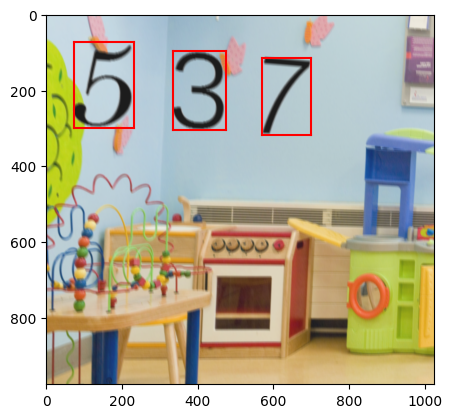

In [27]:
plt.imshow(image)

for i in range(len(image_labels)):
    show_image_with_bounding_box(image_labels[i][1], image_labels[i][2], image_labels[i][3], image_labels[i][4], image.shape[1], image.shape[0])

plt.axis('on')
plt.show()